In [1]:
# Jupyter가 아닌 환경에서도 display()가 동작하도록 하는 shim (전처리 통합본과 동일)
try:
    from IPython.display import display
except Exception:
    display = print

# 금융 TDA 통합본 v2 — 피처 생산 + 시각화

 **전처리 통합본 v2.2와는 여전히 별도 파일.** 팀 공통 전처리(합의사항)는 건드리지 않고,
 이 노트북은 ① 자체적으로 4개 지수 원시 데이터를 받아 TDA 피처를 만들고
 ② §8에서 공유 `GSPC_arrays_20050101_20260101.npz`와 **날짜 기준 join**만 한다.

 ## 목차

 | 절 | 내용 | 성격 |
 |---|---|---|
 | §1–2 | 4개 지수 로드 → 로그 수익률 4D 점구름 | 생산 |
 | §3 | Vietoris–Rips persistent homology (H₀·H₁) | 생산 |
 | §4 | landscape norm + entropy → TDA 피처 8종 | 생산 |
 | §5 | **TDA 이해하기** — 장난감 예제·바코드·Betti 곡선·투영·landscape | 회의 설명용 |
 | §6 | 위기 구간(2008·2020) 스파이크 검증 | 회의 산출물 |
 | §7 | `tda_features_w{W}.csv` 저장 | 생산 |
 | §8 | 공유 npz 병합 + 실험 ①vs③ 미니 데모 | 팀 연결 |
 | §9–10 | 윈도우 민감도(옵션) · 체크리스트 | 검증 |

 ## 설계 요약 (Gidea & Katz 2018 방식)

 | 단계 | 내용 |
 |---|---|
 | 점구름 | 4개 지수(S&P500·DJIA·NASDAQ·Russell2000)의 **일간 로그 수익률을 4차원 좌표**로 사용 |
 | 윈도우 | 길이 `W_TDA`(기본 50)의 슬라이딩 윈도우 → 각 시점마다 (W_TDA × 4) 점구름 |
 | 위상 계산 | Vietoris–Rips filtration → persistent homology **H₀(연결성분)·H₁(루프)** |
 | 벡터화 | persistence landscape의 **L¹·L² norm** (+ persistence entropy) |
 | 기대 현상 | 폭락 구간에서 norm 수준과 변동이 커짐 (2008·2020 검증 완료 — §6) |

 > **Takens embedding을 안 쓰는 이유**: 지수가 4개라 시점마다 자연스러운 4차원 점이 이미 존재.
 > 1개 시계열이면 Takens로 (d, τ)를 골라 좌표를 "만들어야" 하지만, 우리 설계는 그 두 하이퍼파라미터가 아예 없음.

 > **누수(leakage) 없음**: 날짜 t의 TDA 피처는 [t−W_TDA+1, t] 구간, 즉 **과거~당일 데이터만** 사용.
 > 다른 피처(이동평균 괴리율 등)와 같은 타이밍 규약이므로 그대로 X에 붙일 수 있음.

 > **HORIZON 무관**: TDA 피처는 날짜에만 붙는 값이라, 타깃 시계(h=1/5/10/20)가 바뀌어도
 > 이 노트북을 다시 돌릴 필요 없음. npz만 갈아끼우면 됨.

# 0. 준비 — 라이브러리와 전역 설정

In [2]:
# 최초 1회 설치 (전처리 환경에 giotto-tda만 추가하면 됨)
!pip install giotto-tda

import os
import platform
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial.distance import pdist, squareform

import yfinance as yf

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, BettiCurve, PersistenceLandscape

# 한글 폰트 (전처리 통합본과 동일 규약)
_os = platform.system()
plt.rcParams["font.family"] = (
    "Malgun Gothic" if _os == "Windows" else
    "AppleGothic" if _os == "Darwin" else "NanumGothic"
)
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# ── 전역 스위치 ──────────────────────────────────────────────────────────
# 날짜·기간은 3차 회의 확정값과 동일하게 맞춤 (전처리 노트북 §0과 같은 값)
TICKERS = {                     # 4차원 점구름의 좌표축 4개
    "GSPC": "^GSPC",            # S&P500
    "DJI":  "^DJI",             # DJIA
    "IXIC": "^IXIC",            # NASDAQ
    "RUT":  "^RUT",             # Russell 2000
}
START_DATE = "2005-01-01"       # [3차 회의 확정]
END_DATE   = "2026-01-01"       # [3차 회의 확정] end는 미포함 → 2025년 말까지

W_TDA = 50                      # 슬라이딩 윈도우 길이 (Gidea & Katz 기본값)
RUN_SENSITIVITY = False         # True 시 §9에서 {40, 80, 100}도 계산
RUN_VIZ = True                  # §5 시각화 (피처만 다시 뽑을 땐 False로 꺼서 시간 절약)

N_LAYERS = 5                    # landscape 층수 k=1..5
N_BINS   = 200                  # landscape 격자 해상도

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NPZ_PATH = "GSPC_arrays_20050101_20260101.npz"    # 전처리 통합본 §16 산출물 (같은 폴더에 두기)

# §5·§6 시각화에서 비교할 세 시점
#   위기 날짜는 '폭락 당일'이 아니라 norm 피크일 — 50일 윈도우가 위기 데이터로
#   가득 차는 시점에 norm이 최대가 됨 (tda_features에서 확인한 값)
EXAMPLE_DATES = {
    "평상시 (2006-06-15)": "2006-06-15",
    "2008 위기 (2008-12-04)": "2008-12-04",
    "2020 급락 (2020-04-30)": "2020-04-30",
}

print(f"윈도우 W_TDA={W_TDA} | landscape {N_LAYERS}층 × {N_BINS}bins | 시각화 {'ON' if RUN_VIZ else 'OFF'}")
print("지수:", ", ".join(TICKERS.values()))

윈도우 W_TDA=50 | landscape 5층 × 200bins | 시각화 ON
지수: ^GSPC, ^DJI, ^IXIC, ^RUT


# 1. 원시 데이터 — 4개 지수 스냅샷 캐시

 전처리 통합본 §1과 **같은 규약**: 파일명에 기간 포함, 캐시 있으면 다운로드 생략.
 GSPC는 전처리 때 만든 스냅샷을 **그대로 재사용** (팀과 완전히 같은 데이터 보장).

In [4]:
def snapshot_path(short):
    return (f"raw_snapshot_{short}"
            f"_{START_DATE.replace('-','')}_{END_DATE.replace('-','')}.csv")


def load_index(short, ticker):
    """스냅샷이 있으면 읽고, 없으면 다운로드 후 저장 (전처리 §1과 동일 패턴)."""
    path = snapshot_path(short)
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=["Date"], index_col="Date")
        print(f"[캐시] {ticker:6s} ← {path}  {df.shape}")
    else:
        try:
            df = yf.download(tickers=ticker, start=START_DATE, end=END_DATE,
                             auto_adjust=True, progress=False, multi_level_index=False)
        except TypeError:  # 구버전 yfinance 호환
            df = yf.download(tickers=ticker, start=START_DATE, end=END_DATE,
                             auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
        if df.empty:
            raise RuntimeError(f"{ticker} 다운로드 실패 — 잠시 후 재시도")
        df.index.name = "Date"
        df.to_csv(path)
        print(f"[다운로드] {ticker:6s} → {path}  {df.shape}")
    return df[["Close"]].rename(columns={"Close": short})


closes = [load_index(s, t) for s, t in TICKERS.items()]

# 거래일이 지수마다 미세하게 다를 수 있어 inner join (4개 모두 값이 있는 날만 사용)
close_df = pd.concat(closes, axis=1, join="inner").sort_index()
print("\n공통 거래일:", close_df.shape, "|", close_df.index.min().date(), "~", close_df.index.max().date())
display(close_df.tail(3))

[캐시] ^GSPC  ← raw_snapshot_GSPC_20050101_20260101.csv  (5283, 5)
[캐시] ^DJI   ← raw_snapshot_DJI_20050101_20260101.csv  (5283, 5)
[캐시] ^IXIC  ← raw_snapshot_IXIC_20050101_20260101.csv  (5283, 5)
[캐시] ^RUT   ← raw_snapshot_RUT_20050101_20260101.csv  (5283, 5)

공통 거래일: (5283, 4) | 2005-01-03 ~ 2025-12-31


,GSPC,DJI,IXIC,RUT
Date,,,,
2025-12-29,6905.740234,48461.929688,23474.349609,2519.800049
2025-12-30,6896.240234,48367.058594,23419.080078,2500.590088
2025-12-31,6845.500000,48063.289062,23241.990234,2481.909912


# 2. 로그 수익률 → 4차원 점구름

 전처리 확정사항(LOGRET=True)과 동일하게 **로그 수익률**을 좌표로 사용.
 원 논문도 4개 지수의 log return을 그대로 점구름 좌표로 씀 (윈도우 내 별도 스케일링 없음).

In [5]:
logret = np.log(close_df / close_df.shift(1))
logret = logret.dropna()                      # 첫 행(수익률 정의 불가)만 제거
assert np.isfinite(logret.values).all(), "로그 수익률에 inf/NaN 존재!"

print("점구름 좌표 시계열:", logret.shape)
display(logret.describe().round(4))

점구름 좌표 시계열: (5282, 4)


,GSPC,DJI,IXIC,RUT
count,5282.0000,5282.0000,5282.0000,5282.0000
mean,0.0003,0.0003,0.0005,0.0003
std,0.0121,0.0114,0.0137,0.0156
min,-0.1277,-0.1384,-0.1315,-0.1540
25%,-0.0041,-0.0041,-0.0052,-0.0072
50%,0.0007,0.0006,0.0011,0.0008
75%,0.0057,0.0054,0.0072,0.0083
max,0.1096,0.1076,0.1148,0.0898


In [6]:
def build_point_clouds(R: pd.DataFrame, w: int):
    """
    길이 w 슬라이딩 윈도우(보폭 1)로 (n_windows, w, 4) 점구름 배열 생성.
    윈도우의 '끝 날짜'가 그 피처의 소속 날짜 → 과거만 보는 구조 (누수 없음).
    """
    vals = R.values
    n = len(vals)
    pcs = np.stack([vals[i - w + 1 : i + 1] for i in range(w - 1, n)])
    dates = R.index[w - 1 :]
    return pcs, dates


point_clouds, pc_dates = build_point_clouds(logret, W_TDA)
print(f"점구름 {point_clouds.shape} (윈도우 수, 윈도우 길이, 차원)")
print("첫 피처 날짜:", pc_dates[0].date(), "| 마지막:", pc_dates[-1].date())

점구름 (5233, 50, 4) (윈도우 수, 윈도우 길이, 차원)
첫 피처 날짜: 2005-03-16 | 마지막: 2025-12-31


## 2-1. [점검] 점구름 스케일 — TDA 노름이 재는 것이 위상인가 크기인가

**묻는 것**: TDA L-노름이 변동성과 겹치는 것(`TDA_L1_H0` r=0.81)이 위상 구조 때문인가,
아니면 점구름 **크기** 때문인가.

**이론** (정리노트 v4 §2-2) — 점구름을 c배 하면

| 양 | 배율 |
|---|---|
| Lᵖ 노름 | c^(1+1/p) — L¹은 c², L²는 c^1.5 |
| 지속 엔트로피 | c⁰ (불변) |

Vietoris–Rips가 거리행렬만으로 결정되기 때문. 점을 c배 하면 모든 birth·death가 c배가 되고,
랜드스케이프는 밑변·높이가 둘 다 c배인 삼각형이 된다.

아래 §A–§F는 그 이론이 실제 우리 데이터에서 성립하는지만 본다.
**읽기 전용** — 아무 변수도 덮어쓰지 않고 파일도 만들지 않는다.

> §D가 §7 산출물 `tda_features_w{W_TDA}.csv` 를 읽는다. 파라미터를 바꿔 다시 계산하는
> 중이라면 §7까지 한 번 돌린 뒤 이 절을 실행할 것 (아니면 디스크의 옛 파일을 읽는다).

### §A. 점구름 원본 찾기

네 지수 로그수익률 DataFrame(GSPC·DJI·IXIC·RUT 4열, 날짜 인덱스 — 슬라이딩 윈도우로
자르기 **직전**의 그것)을 전역에서 자동으로 찾는다. 실패하면 맨 위 `RET` 에 직접 넣으면 된다.

In [7]:
# ============================================================================
# [점검] 점구름 스케일 — 2026-09-22
# §A. 점구름 원본 찾기
# ============================================================================
import numpy as np
import pandas as pd
from itertools import combinations

RET = None          # ← 자동 탐색 실패 시 여기에 직접: RET = logret
W = W_TDA           # 윈도우 길이 (§0의 W_TDA 를 그대로 사용 — 노트북과 항상 일치)
TDA_CSV = f"tda_features_w{W_TDA}.csv"

INDEX_WORDS = ("GSPC", "SPX", "S&P", "SP500", "DJI", "DJIA", "DOW",
               "IXIC", "NASDAQ", "NDX", "RUT", "RUSSELL")

if RET is None:
    cands = []
    for name, v in list(globals().items()):
        if name.startswith("_") or not isinstance(v, pd.DataFrame):
            continue
        if v.shape[1] != 4 or not isinstance(v.index, pd.DatetimeIndex):
            continue
        num = v.select_dtypes("number")
        if num.shape[1] != 4 or len(v) < 1000:
            continue
        if not (num.abs().max().max() < 0.5 and abs(num.mean().mean()) < 0.01):
            continue
        # 열 이름이 지수 이름처럼 보이는 것만 (초과수익률 등 파생 프레임 배제)
        hit = sum(any(w in str(c).upper() for w in INDEX_WORDS) for c in v.columns)
        cands.append((name, v, hit))

    named = [c for c in cands if c[2] == 4]
    print("자동 탐색 후보:", [(c[0], f"지수명 {c[2]}/4") for c in cands] or "없음")
    if len(named) == 1:
        RET = named[0][1]
        print(f"  → '{named[0][0]}' 사용 (4열 모두 지수 이름)")
    elif len(named) > 1:
        raise SystemExit(
            f"후보가 여럿입니다: {[c[0] for c in named]}\n"
            "  이 셀 맨 위 RET 에 직접 지정해 주세요.")
    elif cands:
        raise SystemExit(
            f"열 이름이 지수 이름으로 안 보입니다: "
            f"{[(c[0], list(c[1].columns)) for c in cands]}\n"
            "  맞는 것이 있으면 RET 에 직접 지정해 주세요.\n"
            "  ⚠ 초과수익률(S&P 대비) 프레임을 넣으면 안 됩니다. 각 지수의 '자기 수익률'이어야 합니다.")

assert RET is not None, (
    "네 지수 로그수익률 DataFrame을 못 찾았습니다.\n"
    "  이 셀 맨 위 RET 에 직접 넣어주세요. 예) RET = logret\n"
    "  조건: 4열 · 날짜 인덱스 · 슬라이딩 윈도우로 자르기 직전 상태")

RET = RET.select_dtypes("number").dropna()
print(f"\n점구름 원본: {RET.shape}  {RET.index.min().date()} ~ {RET.index.max().date()}")
print("열:", list(RET.columns))

자동 탐색 후보: [('logret', '지수명 4/4')]
  → 'logret' 사용 (4열 모두 지수 이름)

점구름 원본: (5282, 4)  2005-01-04 ~ 2025-12-31
열: ['GSPC', 'DJI', 'IXIC', 'RUT']


### §B. 스케일 정의와 공식 검증

점구름의 "크기"를 **RMS 쌍거리**로 잰다. 항등식

$$\frac{1}{\binom{W}{2}}\sum_{a<b}\lVert p_a-p_b\rVert^2 \;=\; 2\sum_{d=1}^{4}s_d^2$$

덕분에 1,225쌍 계산을 분산 4번으로 대체할 수 있다 (`ddof=1` 이어야 정확히 맞는다).
지름길이 전수계산과 같은지 무작위 5개 창에서 확인한다.

In [8]:
# ============================================================================
# §B. 스케일 공식 검증 — 지름길이 전수계산과 같은가
#     항등식: 모든 쌍의 거리제곱 평균 = 2 × (차원별 표본분산의 합)
# ============================================================================
# ⚠ min_count=4 가 핵심. 이게 없으면 워밍업 구간(처음 W-1행)에서 rolling이 NaN을
#   내는데 pandas의 sum()이 NaN을 0으로 삼켜, 스케일 0인 가짜 창이 생긴다.
scale = np.sqrt(
    2 * RET.rolling(W).var(ddof=1).sum(axis=1, min_count=4)).rename("scale")


def brute_rms(end_i):
    """end_i 직전 W일 점구름의 RMS 쌍거리 — 정직하게 전부 계산"""
    P = RET.iloc[end_i - W:end_i].values
    return np.sqrt(np.mean([np.sum((P[a] - P[b]) ** 2)
                            for a, b in combinations(range(W), 2)]))


print(f"§B 공식 검증 ({W*(W-1)//2}쌍 전수계산 vs 지름길)")
rng = np.random.default_rng(0)
for i in rng.choice(range(W, len(RET)), 5, replace=False):
    b, s = brute_rms(i), scale.iloc[i - 1]
    flag = "OK" if abs(b - s) < 1e-10 else "!! 불일치"
    print(f"  {str(RET.index[i-1].date()):>12s}  전수 {b:.6f}  지름길 {s:.6f}  {flag}")

§B 공식 검증 (1225쌍 전수계산 vs 지름길)
    2018-06-07  전수 0.025615  지름길 0.025615  OK
    2015-10-27  전수 0.042418  지름길 0.042418  OK
    2010-10-21  전수 0.031824  지름길 0.031824  OK
    2011-08-05  전수 0.037885  지름길 0.037885  OK
    2022-11-11  전수 0.053782  지름길 0.053782  OK


### §C. 표준화 여부 판정

창마다 점구름을 표준화했다면 스케일이 거의 일정해야 한다. 변동계수(표준편차/평균)가
작으면 표준화된 것. 스케일 0인 창이 있으면 그건 데이터 문제 신호다.

In [9]:
# ============================================================================
# §C. 표준화 여부 판정
# ============================================================================
s = scale.dropna()
cv = s.std() / s.mean()
print(f"§C 스케일 분포 — 최소 {s.min():.5f} / 중앙 {s.median():.5f} / 최대 {s.max():.5f}")
print(f"   변동계수 {cv:.3f}  →  " +
      ("표준화된 점구름으로 보임 (스케일이 거의 일정)" if cv < 0.1
       else "표준화 안 된 원 스케일 (창마다 크게 다름)"))
print(f"   스케일 0인 창: {int((s == 0).sum())}개  (0이어야 정상)")
if (s == 0).sum():
    print("   해당 날짜:", [str(d.date()) for d in s[s == 0].index[:10]])
    print(f"   ※ {W}일 내내 네 지수가 모두 동일하다는 뜻 — 정상 데이터에서는 불가능.")
    print("     min_count 처리가 빠졌거나 원본에 중복 행이 있는지 확인할 것")

§C 스케일 분포 — 최소 0.01210 / 중앙 0.02729 / 최대 0.13762
   변동계수 0.560  →  표준화 안 된 원 스케일 (창마다 크게 다름)
   스케일 0인 창: 0개  (0이어야 정상)


### §D. TDA 피처가 스케일로 얼마나 설명되나

각 피처의 **vs 변동성** · **vs 스케일** 상관과, 스케일로 나눈 뒤의 상관을 나란히 본다.
누수 방지를 위해 **train 70% 구간에서만** 계산한다.

읽는 법

- `vs 스케일` 이 `vs 변동성` 만큼 높다 → 그 피처는 변동성이 아니라 **크기**를 재고 있다
- `스케일 나눈 뒤` 상관이 크게 떨어진다 → 겹침의 원인이 스케일이었다
- **PE는 스케일 불변량**이라, 스케일로 나누면 오히려 상관이 생긴다.
  그건 발견이 아니라 연산의 부산물이니 해석하지 말 것.

In [10]:
# ============================================================================
# §D. TDA 피처가 스케일로 얼마나 설명되나
# ============================================================================
tda = pd.read_csv(TDA_CSV, encoding="utf-8-sig", index_col="Date", parse_dates=True)

# Volatility_20 은 S&P 열에서 뽑는다 (열 순서에 기대지 않고 이름으로 찾음)
sp = [c for c in RET.columns
      if any(w in str(c).upper() for w in ("GSPC", "SPX", "S&P", "SP500"))]
assert sp, f"S&P 열을 못 찾았습니다. RET 열: {list(RET.columns)}"
vol = RET[sp[0]].rolling(20).std().rename("Volatility_20")
print(f"   Volatility_20 산출 열: '{sp[0]}'")

J = pd.concat([scale, tda, vol], axis=1, sort=False).dropna()
J = J[J["scale"] > 0]
TR = J.loc[:J.index[int(len(J) * 0.70)]]          # train 구간에서만 (누수 방지)
print(f"\n§D train n = {len(TR)}")
print(f"   스케일 vs Volatility_20 상관 = {TR['scale'].corr(TR['Volatility_20']):.3f}")

print(f"\n{'피처':<18s}{'vs 변동성':>10s}{'vs 스케일':>10s}{'스케일 나눈 뒤':>15s}")
for c in tda.columns:
    r_vol = TR[c].corr(TR["Volatility_20"])
    r_scl = TR[c].corr(TR["scale"])
    r_res = (TR[c] / TR["scale"]).corr(TR["Volatility_20"])
    print(f"{c:<18s}{r_vol:10.3f}{r_scl:10.3f}{r_res:15.3f}")

   Volatility_20 산출 열: 'GSPC'



§D train n = 3650
   스케일 vs Volatility_20 상관 = 0.898

피처                    vs 변동성    vs 스케일       스케일 나눈 뒤
TDA_L1_H0              0.813     0.804          0.509
TDA_L1_H1              0.461     0.583          0.000
TDA_L2_H0              0.804     0.807          0.215
TDA_L2_H1              0.462     0.578         -0.128
TDA_PE_H0             -0.075    -0.012         -0.743
TDA_PE_H1             -0.223    -0.250         -0.619
TDA_L1_H1_diff1        0.017     0.007          0.004
TDA_L1_H1_std20        0.643     0.761          0.144


### §E. 로그-로그 기울기 — 이론값과 맞는가

`log(노름) ~ k·log(스케일)` 의 기울기 k를 재서 이론값(L¹→2.0, L²→1.5, PE→0.0)과 비교한다.

실측이 이론보다 **작으면**, 점구름이 커질 때 '모양'도 같이 바뀐다는 뜻.
즉 노름에 크기 말고 형태 성분이 남아 있다 — TDA가 완전히 중복은 아니라는 근거.

In [11]:
# ============================================================================
# §E. 로그-로그 기울기 — 이론값과 맞는가
#     L¹ → 2.0, L² → 1.5, PE → 0.0
# ============================================================================
THEORY = {"TDA_L1_H0": 2.0, "TDA_L1_H1": 2.0, "TDA_L2_H0": 1.5, "TDA_L2_H1": 1.5,
          "TDA_PE_H0": 0.0, "TDA_PE_H1": 0.0}
print("§E 로그-로그 기울기 (노름 ~ 스케일^k)")
print(f"{'피처':<18s}{'실측 k':>9s}{'이론':>7s}{'차이':>8s}")
for c, th in THEORY.items():
    if c not in TR.columns:
        continue
    m = (TR[c] > 0) & (TR["scale"] > 0)
    k = np.polyfit(np.log(TR.loc[m, "scale"]), np.log(TR.loc[m, c]), 1)[0]
    print(f"{c:<18s}{k:9.3f}{th:7.1f}{k-th:8.3f}")

§E 로그-로그 기울기 (노름 ~ 스케일^k)


피처                     실측 k     이론      차이
TDA_L1_H0             1.466    2.0  -0.534
TDA_L1_H1             0.913    2.0  -1.087
TDA_L2_H0             1.104    1.5  -0.396


TDA_L2_H1             0.730    1.5  -0.770
TDA_PE_H0            -0.000    0.0  -0.000
TDA_PE_H1            -0.215    0.0  -0.215


### §F. (선택) H₀ = 최소생성나무 확인

H₀ 막대의 death 시각은 성분들이 합쳐지는 거리 = **MST 간선 길이**와 같아야 한다.
같다면 'H₀ 노름은 MST 길이의 함수'가 확정되고, 그건 곧 점구름 크기다.

In [12]:
# ============================================================================
# §F. (선택) H₀ = 최소생성나무 확인
# ============================================================================
try:
    from scipy.sparse.csgraph import minimum_spanning_tree
    from scipy.spatial.distance import squareform, pdist
    i = len(RET) // 2
    P = RET.iloc[i - W:i].values
    mst = minimum_spanning_tree(squareform(pdist(P))).toarray()
    edges = np.sort(mst[mst > 0])
    print(f"§F MST 간선 {len(edges)}개 (점 {W}개 → {W-1}개여야 정상)")
    print(f"   합계 {edges.sum():.5f} · 최대 {edges.max():.5f}")
    print("   → 같은 창의 H₀ death 값들과 대조해 보세요. 같으면")
    print("      'H₀ 노름은 MST 길이의 함수'가 확정되고, 그건 곧 점구름 크기입니다.")
except Exception as e:
    print(f"§F 건너뜀 ({e})")

print("\n점검 완료.")

§F MST 간선 49개 (점 50개 → 49개여야 정상)
   합계 0.18579 · 최대 0.01666
   → 같은 창의 H₀ death 값들과 대조해 보세요. 같으면
      'H₀ 노름은 MST 길이의 함수'가 확정되고, 그건 곧 점구름 크기입니다.

점검 완료.



# 3. Vietoris–Rips persistent homology (H₀·H₁)

 - **H₀** = 연결 성분의 생성·소멸 (점들이 뭉치는 스케일 구조)
 - **H₁** = 루프(1차원 구멍)의 생성·소멸 — 논문이 폭락 전조로 주목한 차원
 - 전체 윈도우(~5,000개)에 대해 일괄 계산. 윈도우당 점이 50개뿐이라 수십 초 내 종료.

In [7]:
def compute_diagrams(pcs):
    VR = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=(0, 1),
        n_jobs=-1,
    )
    return VR.fit_transform(pcs)


t0 = time.time()
diagrams = compute_diagrams(point_clouds)
print(f"persistence diagram {diagrams.shape}  ({time.time()-t0:.1f}초)")
# shape = (윈도우 수, 최대 특징 수, 3) — 각 행이 (birth, death, homology 차원)


def diagram_at(date_str):
    """해당 날짜(이후 첫 거래일)의 다이어그램·점구름·실제 날짜 반환 — §5·§6 재활용."""
    pos = int(pc_dates.searchsorted(pd.Timestamp(date_str)))
    pos = min(pos, len(pc_dates) - 1)
    return diagrams[pos], point_clouds[pos], pc_dates[pos]

persistence diagram (5233, 66, 3)  (8.3초)


# 4. 벡터화 — persistence landscape norm + entropy → TDA 피처

 다이어그램(점 집합)은 ML에 바로 못 넣으므로 **숫자 몇 개로 요약**:

 | 피처 | 의미 |
 |---|---|
 | `TDA_L1_H0`, `TDA_L1_H1` | landscape의 L¹ norm — "위상 구조의 총량" (논문의 핵심 지표) |
 | `TDA_L2_H0`, `TDA_L2_H1` | landscape의 L² norm — 큰 구조에 더 민감한 버전 |
 | `TDA_PE_H0`, `TDA_PE_H1` | persistence entropy — 수명 분포의 불균일도 |
 | `TDA_L1_H1_diff1` | L¹(H₁)의 1일 변화 — norm의 '움직임' |
 | `TDA_L1_H1_std20` | L¹(H₁)의 20일 롤링 표준편차 — 논문이 강조한 "폭락 전 분산 증가" |

 `Amplitude(metric="landscape", order=None)`는 landscape의 Lᵖ norm을 homology 차원별로
 돌려줌 — 논문의 L¹/L² norm 정의와 일치.

In [8]:
def diagrams_to_features(dgms, dates, n_layers=N_LAYERS, n_bins=N_BINS):
    amp_l1 = Amplitude(metric="landscape",
                       metric_params={"p": 1, "n_layers": n_layers, "n_bins": n_bins},
                       order=None).fit_transform(dgms)
    amp_l2 = Amplitude(metric="landscape",
                       metric_params={"p": 2, "n_layers": n_layers, "n_bins": n_bins},
                       order=None).fit_transform(dgms)
    pent = PersistenceEntropy(normalize=False, nan_fill_value=0.0).fit_transform(dgms)

    f = pd.DataFrame(
        {
            "TDA_L1_H0": amp_l1[:, 0], "TDA_L1_H1": amp_l1[:, 1],
            "TDA_L2_H0": amp_l2[:, 0], "TDA_L2_H1": amp_l2[:, 1],
            "TDA_PE_H0": pent[:, 0],   "TDA_PE_H1": pent[:, 1],
        },
        index=dates,
    )
    # 파생 2종 — 팀 규약대로 min_periods=window (미완성 윈도우 차단)
    f["TDA_L1_H1_diff1"] = f["TDA_L1_H1"].diff(1)
    f["TDA_L1_H1_std20"] = f["TDA_L1_H1"].rolling(20, min_periods=20).std()
    f.index.name = "Date"
    return f


tda_features = diagrams_to_features(diagrams, pc_dates)
print("TDA 피처:", tda_features.shape)
print("파생 피처 워밍업 NaN (앞 20행 근처, 정상):", int(tda_features.isna().sum().sum()))
display(tda_features.tail(3).round(6))

TDA 피처: (5233, 8)
파생 피처 워밍업 NaN (앞 20행 근처, 정상): 20


,TDA_L1_H0,TDA_L1_H1,TDA_L2_H0,TDA_L2_H1,TDA_PE_H0,TDA_PE_H1,TDA_L1_H1_diff1,TDA_L1_H1_std20
Date,,,,,,,,
2025-12-29,0.000161,0.000003,0.000796,0.000036,5.519295,3.301443,-0.000003,0.000002
2025-12-30,0.000161,0.000003,0.000796,0.000036,5.514630,3.301443,0.000000,0.000002
2025-12-31,0.000156,0.000004,0.000772,0.000044,5.516796,3.247791,0.000001,0.000002


## 4.5. 교차지수 피처 — 실험 ②용  *(TDA와 별개 산출물)*

실험 ②는 "**다지수 정보 자체**의 기여"를 재는 대조군. ③(+TDA)이 좋아졌을 때
"TDA 덕분인가, 그냥 타 지수를 봐서인가"를 가르는 역할이므로 ③과 짝을 이뤄야 함.

### 설계 원칙 — 왜 '수준'이 아니라 '상대 구조'인가

타 지수의 원시 수익률을 그대로 넣으면 22개 피처와 **상관 0.90~0.97**로 사실상 중복.
실제 확인값: DJI 원시 수익률 0.968(Return_1d), RUT 20일 변동성 0.953(Volatility_20).
반면 **DJI 초과수익률 0.354**, **지수간 20일 평균상관 0.444**로 새로운 정보.
→ **GSPC 대비 상대량**으로 설계. Ridge/Lasso는 다중공선성에 민감하므로 특히 중요 (다영님 파트).

| 피처 | 의미 |
|---|---|
| `X_exc1d_{DJI,IXIC,RUT}` | GSPC 대비 초과 수익률 (1일) |
| `X_exc5d_{DJI,IXIC,RUT}` | 초과 수익률 5일 누적 |
| `X_breadth_up` | 4개 중 상승한 지수 개수 (0~4) — 시장 폭 |
| `X_disp_std` | 당일 4개 지수 수익률의 표준편차 |
| `X_corr20_mean` | 지수쌍 20일 평균 상관 — 동조화 수준 |
| `X_corr20_chg5` | 동조화의 5일 변화 |
| `X_volratio_RUT_GSPC` | 소형주/대형주 변동성 비율 — 위험선호 대리지표 |
| `X_lead_RUT_1d` | 전일 소형주 초과수익 — 소형주 선행 가설 |

> **누수 없음**: 모두 날짜 t의 과거~당일 값만 사용 (TDA 피처와 동일 규약).

In [9]:
_oth = ["DJI", "IXIC", "RUT"]
_all = ["GSPC"] + _oth

cross_features = pd.DataFrame(index=logret.index)

# ① GSPC 대비 초과 수익률 (수준이 아닌 '차이' → 22피처와 중복 회피)
for t in _oth:
    exc = logret[t] - logret["GSPC"]
    cross_features[f"X_exc1d_{t}"] = exc
    cross_features[f"X_exc5d_{t}"] = exc.rolling(5, min_periods=5).sum()

# ② 시장 폭·분산
cross_features["X_breadth_up"] = (logret[_all] > 0).sum(axis=1)
cross_features["X_disp_std"] = logret[_all].std(axis=1)

# ③ 동조화 (지수쌍 평균 상관) — 위기 때 상관이 1로 붙는 현상 포착
_iu = np.triu_indices(len(_all), k=1)
cross_features["X_corr20_mean"] = (
    logret[_all].rolling(20, min_periods=20).corr()
    .groupby(level=0).apply(lambda m: m.values[_iu].mean())
)
cross_features["X_corr20_chg5"] = cross_features["X_corr20_mean"].diff(5)

# ④ 위험선호 대리지표
cross_features["X_volratio_RUT_GSPC"] = (
    logret["RUT"].rolling(20, min_periods=20).std()
    / logret["GSPC"].rolling(20, min_periods=20).std()
)
cross_features["X_lead_RUT_1d"] = (logret["RUT"] - logret["GSPC"]).shift(1)

cross_features.index.name = "Date"

_cc = cross_features.corr().abs().values.copy()
np.fill_diagonal(_cc, 0)
print("교차지수 피처:", cross_features.shape)
print("워밍업 NaN (앞 20행 근처, 정상):", int(cross_features.isna().sum().sum()))
print("피처 내부 최대 상관:", round(_cc.max(), 3), "(0.9 미만이어야 안전)")
display(cross_features.tail(3).round(4))

out_cross = "cross_index_features.csv"
cross_features.to_csv(out_cross, encoding="utf-8-sig")
print("저장 완료:", out_cross)

교차지수 피처: (5282, 12)
워밍업 NaN (앞 20행 근처, 정상): 75
피처 내부 최대 상관: 0.553 (0.9 미만이어야 안전)


,X_exc1d_DJI,X_exc5d_DJI,X_exc1d_IXIC,X_exc5d_IXIC,X_exc1d_RUT,X_exc5d_RUT,X_breadth_up,X_disp_std,X_corr20_mean,X_corr20_chg5,X_volratio_RUT_GSPC,X_lead_RUT_1d
Date,,,,,,,,,,,,
2025-12-29,-0.0016,-0.0036,-0.0015,-0.0032,-0.0023,-0.0142,0,0.0010,0.6907,-0.0463,1.7012,-0.0051
2025-12-30,-0.0006,-0.0025,-0.0010,-0.0030,-0.0063,-0.0256,0,0.0029,0.6793,-0.0535,1.6926,-0.0023
2025-12-31,0.0011,0.0015,-0.0002,-0.0043,-0.0001,-0.0142,0,0.0006,0.7013,-0.0179,1.6436,-0.0063


저장 완료: cross_index_features.csv


 ---
# 5. TDA 이해하기 — 회의 설명용 시각화 5종

 §3의 다이어그램을 **그대로 재활용**하므로 추가 계산은 장난감 예제뿐.
 (`RUN_VIZ = False`로 끄고 피처만 뽑을 수도 있음)

 | 그림 | 답하는 질문 |
 |---|---|
 | viz1 장난감 예제 | "풍선 불기·고리 탄생/사망이 실제로 뭔가?" |
 | viz2 실데이터 바코드 + 다이어그램 | "우리 데이터의 birth/death를 그림으로 보면?" |
 | viz3 Betti 곡선 | "반지름을 키우면 구조가 어떻게 변하나?" |
 | viz4 4D 점구름 2D 투영 | "4차원 점구름도 어쨌든 볼 수는 없나?" |
 | viz5 landscape 산맥 | "L¹/L² norm이 재는 '면적'이 뭔가?" |

 > **왜 장난감 예제부터?** 우리 점구름은 4차원이라 그 자체는 못 그림. 하지만 VR·H₀·H₁의
 > **개념은 차원과 무관**해서, 2차원 예제에서 정확히 보여준 뒤 "같은 계산을 4차원에서 한다"고
 > 연결하는 게 가장 정직하고 이해도 빠른 방법.

In [10]:
def draw_vr_complex(ax, pts, eps, title, show_balls=True):
    """점구름 pts 위에 반지름 eps의 VR 복합체(점·엣지·삼각형 = 0·1·2단체)를 그림.
    show_balls=True면 각 점에 반지름 eps/2의 '풍선'을 함께 표시 —
    두 풍선이 닿는 것(거리 ≤ eps)이 곧 엣지 연결 조건임을 눈으로 보여줌."""
    n = len(pts)
    D = squareform(pdist(pts))
    if show_balls:                           # 풍선 (반지름 eps/2)
        ball_alpha = 0.10 if eps <= 0.8 else 0.035   # ε 크면 옅게 (화면 덮임 방지)
        for p in pts:
            ax.add_patch(plt.Circle(p, eps / 2, facecolor="tab:orange",
                                    alpha=ball_alpha, edgecolor="tab:orange", lw=0.6))
    for i in range(n):                       # 2-단체 (삼각형): 세 변이 모두 eps 이하
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                if D[i, j] <= eps and D[j, k] <= eps and D[i, k] <= eps:
                    ax.add_patch(Polygon(pts[[i, j, k]], closed=True,
                                         facecolor="tab:blue", alpha=0.15, edgecolor="none"))
    for i in range(n):                       # 1-단체 (엣지)
        for j in range(i + 1, n):
            if D[i, j] <= eps:
                ax.plot(pts[[i, j], 0], pts[[i, j], 1], color="tab:blue", lw=1.6, alpha=0.85)
    ax.scatter(pts[:, 0], pts[:, 1], s=45, c="black", zorder=3)   # 0-단체 (점)
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")
    m = 1.0 + eps / 2 + 0.35                 # 풍선이 잘리지 않게 여백 고정
    ax.set_xlim(-m, m); ax.set_ylim(-m, m)
    ax.set_xticks([]); ax.set_yticks([])
 
 
def draw_barcode(ax, dgm, title, eps_marks=None):
    """다이어그램(birth, death, dim) → H0(파랑)·H1(빨강) 바코드."""
    y = 0
    for dim, color in [(0, "tab:blue"), (1, "tab:red")]:
        bars = dgm[(dgm[:, 2] == dim) & (dgm[:, 1] > dgm[:, 0])]
        bars = bars[np.argsort(bars[:, 1] - bars[:, 0])]  # 수명 짧은 것부터 아래에
        for b, d, _ in bars:
            ax.hlines(y, b, d, color=color, lw=2.2)
            y += 1
        y += 2
    if eps_marks:
        for e in eps_marks:
            ax.axvline(e, color="gray", ls="--", lw=0.8)
    ax.set_yticks([])
    ax.set_xlabel("ε (반지름)")
    ax.set_title(title, fontsize=10)
 
 
def draw_diagram(ax, dgm, title):
    """persistence diagram 산점도 (birth vs death)."""
    for dim, color, marker in [(0, "tab:blue", "o"), (1, "tab:red", "^")]:
        pts = dgm[dgm[:, 2] == dim]
        pts = pts[pts[:, 1] > pts[:, 0]]
        ax.scatter(pts[:, 0], pts[:, 1], s=18, c=color, marker=marker, label=f"$H_{dim}$", alpha=0.8)
    lim = max(dgm[:, 1].max(), 1e-6) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlabel("birth"); ax.set_ylabel("death")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

### viz1. 장난감 예제 — VR 복합체가 자라는 과정과 바코드

 2차원 평면에 **고리 모양으로 흩어진 점 20개**를 만들고, 반지름 ε를 키우면서
 점(0-단체)·선(1-단체)·삼각형(2-단체)이 자라는 걸 그림 = **단체 복합체 그 자체**.

 - ε 작음: 점만 → 성분 20개 (H₀=20)
 - ε 중간: 이웃끼리 이어져 **큰 고리 1개** 완성 (H₁ 탄생)
 - ε 큼: 삼각형들이 안쪽을 메워 고리 사망 (H₁ 사망)

 맨 오른쪽 **바코드**가 이 이야기의 기록: 막대 하나 = 특징 하나, 왼끝 = birth, 오른끝 = death.
 **"긴 막대 = 진짜 구조, 짧은 막대 = 노이즈"** — TDA의 핵심 문장.

 > H₀ 막대가 점 개수보다 1개 적은 이유: 마지막까지 남는 성분 1개는 영원히 안 죽어서(∞)
 > giotto-tda가 목록에서 제외함.

큰 고리: birth=0.422, death=1.663 → 수명 1.241


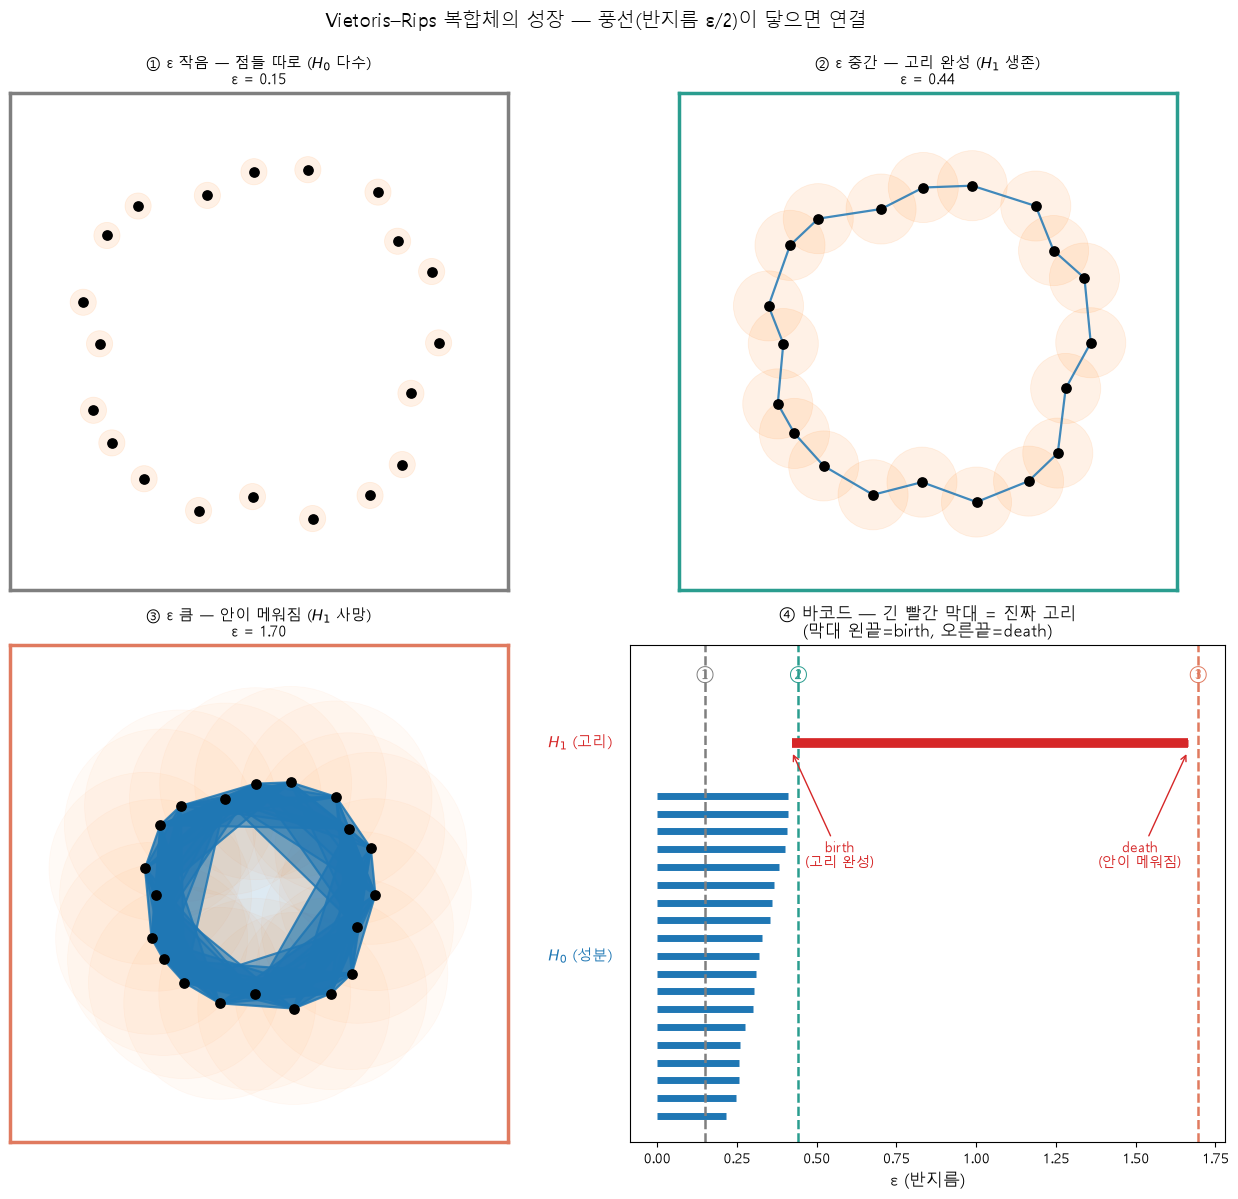

In [11]:
if RUN_VIZ:
    theta = np.linspace(0, 2 * np.pi, 20, endpoint=False)
    ring = np.c_[np.cos(theta), np.sin(theta)] + np.random.normal(0, 0.06, (20, 2))

    VR2 = VietorisRipsPersistence(homology_dimensions=(0, 1))
    ring_dgm = VR2.fit_transform([ring])[0]
    h1 = ring_dgm[ring_dgm[:, 2] == 1]
    main_loop = h1[np.argmax(h1[:, 1] - h1[:, 0])]
    print(f"큰 고리: birth={main_loop[0]:.3f}, death={main_loop[1]:.3f} → 수명 {main_loop[1]-main_loop[0]:.3f}")

    eps_stages = [0.15, max(0.40, main_loop[0] * 1.05), main_loop[1] * 1.02]
    stage_colors = ["#7f7f7f", "#2a9d8f", "#e07a5f"]        # ①회색 ②청록 ③적갈
    stage_names = ["① ε 작음 — 점들 따로 ($H_0$ 다수)",
                   "② ε 중간 — 고리 완성 ($H_1$ 생존)",
                   "③ ε 큼 — 안이 메워짐 ($H_1$ 사망)"]

    # 2×2 배치: ①②③ + 바코드(오른쪽 아래)
    fig, axes = plt.subplots(2, 2, figsize=(13, 12))
    axes = axes.ravel()

    # ── ①②③: 풍선 + 복합체 성장 ──
    for ax, eps, name, c in zip(axes[:3], eps_stages, stage_names, stage_colors):
        draw_vr_complex(ax, ring, eps, f"{name}\nε = {eps:.2f}")
        for spine in ax.spines.values():                     # 테두리 색으로 단계 표시
            spine.set_edgecolor(c); spine.set_linewidth(2.5)

    # ── ④: 바코드 (토이 전용 — 굵은 막대 + birth/death 주석) ──
    axb = axes[3]
    y = 0
    y_main = None
    for dim, color, lab in [(0, "tab:blue", "$H_0$ (성분)"), (1, "tab:red", "$H_1$ (고리)")]:
        bars = ring_dgm[(ring_dgm[:, 2] == dim) & (ring_dgm[:, 1] > ring_dgm[:, 0])]
        bars = bars[np.argsort(bars[:, 1] - bars[:, 0])]
        y0 = y
        for b, d, _ in bars:
            axb.hlines(y, b, d, color=color, lw=5)
            if dim == 1 and np.isclose(d - b, main_loop[1] - main_loop[0]):
                y_main = y
            y += 1
        axb.text(-0.03, (y0 + y - 1) / 2, lab, ha="right", va="center",
                 fontsize=11, color=color, transform=axb.get_yaxis_transform())
        y += 2

    for e, c, mark in zip(eps_stages, stage_colors, ["①", "②", "③"]):
        axb.axvline(e, color=c, ls="--", lw=1.8)
        axb.text(e, y + 0.3, mark, ha="center", va="bottom", fontsize=14, color=c)

    # 큰 고리 막대에 birth/death 화살표
    axb.annotate("birth\n(고리 완성)", xy=(main_loop[0], y_main - 0.5), xytext=(main_loop[0] + 0.15, y_main - 7),
                 ha="center", fontsize=10, color="tab:red",
                 arrowprops=dict(arrowstyle="->", color="tab:red"))
    axb.annotate("death\n(안이 메워짐)", xy=(main_loop[1], y_main - 0.5), xytext=(main_loop[1] - 0.15, y_main - 7),
                 ha="center", fontsize=10, color="tab:red",
                 arrowprops=dict(arrowstyle="->", color="tab:red"))
    axb.hlines(y_main, main_loop[0], main_loop[1], color="tab:red", lw=7)  # 강조 덧칠

    axb.set_ylim(-1.5, y + 2.5)
    axb.set_yticks([])
    axb.set_xlabel("ε (반지름)", fontsize=12)
    axb.set_title("④ 바코드 — 긴 빨간 막대 = 진짜 고리\n(막대 왼끝=birth, 오른끝=death)", fontsize=12)

    plt.suptitle("Vietoris–Rips 복합체의 성장 — 풍선(반지름 ε/2)이 닿으면 연결", y=0.995, fontsize=14)
    plt.tight_layout()
    plt.savefig("viz1_vr_growth_toy.png", dpi=140, bbox_inches="tight")
    plt.show()

### viz2. 실데이터 바코드 + persistence diagram — 평상시 vs 2008 vs 2020

 바코드와 다이어그램은 **같은 정보의 두 표현**: 다이어그램의 점 (birth, death) 하나가
 바코드의 막대 [birth, death] 하나와 일대일 대응.

 볼 포인트:
 - **파란 막대(H₀)의 오른끝 분포** = 점들이 서로 붙는 거리들 = 그 50일 시장의 "퍼짐 정도".
   위기 윈도우일수록 막대들이 오른쪽으로 길게 늘어남.
 - 다이어그램에서 H₀가 세로축(x=0)에 쌓이는 건 정의상 필연 — ε=0에서 모든 점이 각자 성분이라
   birth가 전부 0. **정보는 y좌표(합쳐지는 반지름)의 분포**에 있음.
 - **빨간 막대(H₁)**: 개별 수명은 짧지만(다이어그램에서 대각선 근처) 위기 때 개수·스케일이 커짐 —
   그 "총량"을 재는 게 landscape norm.

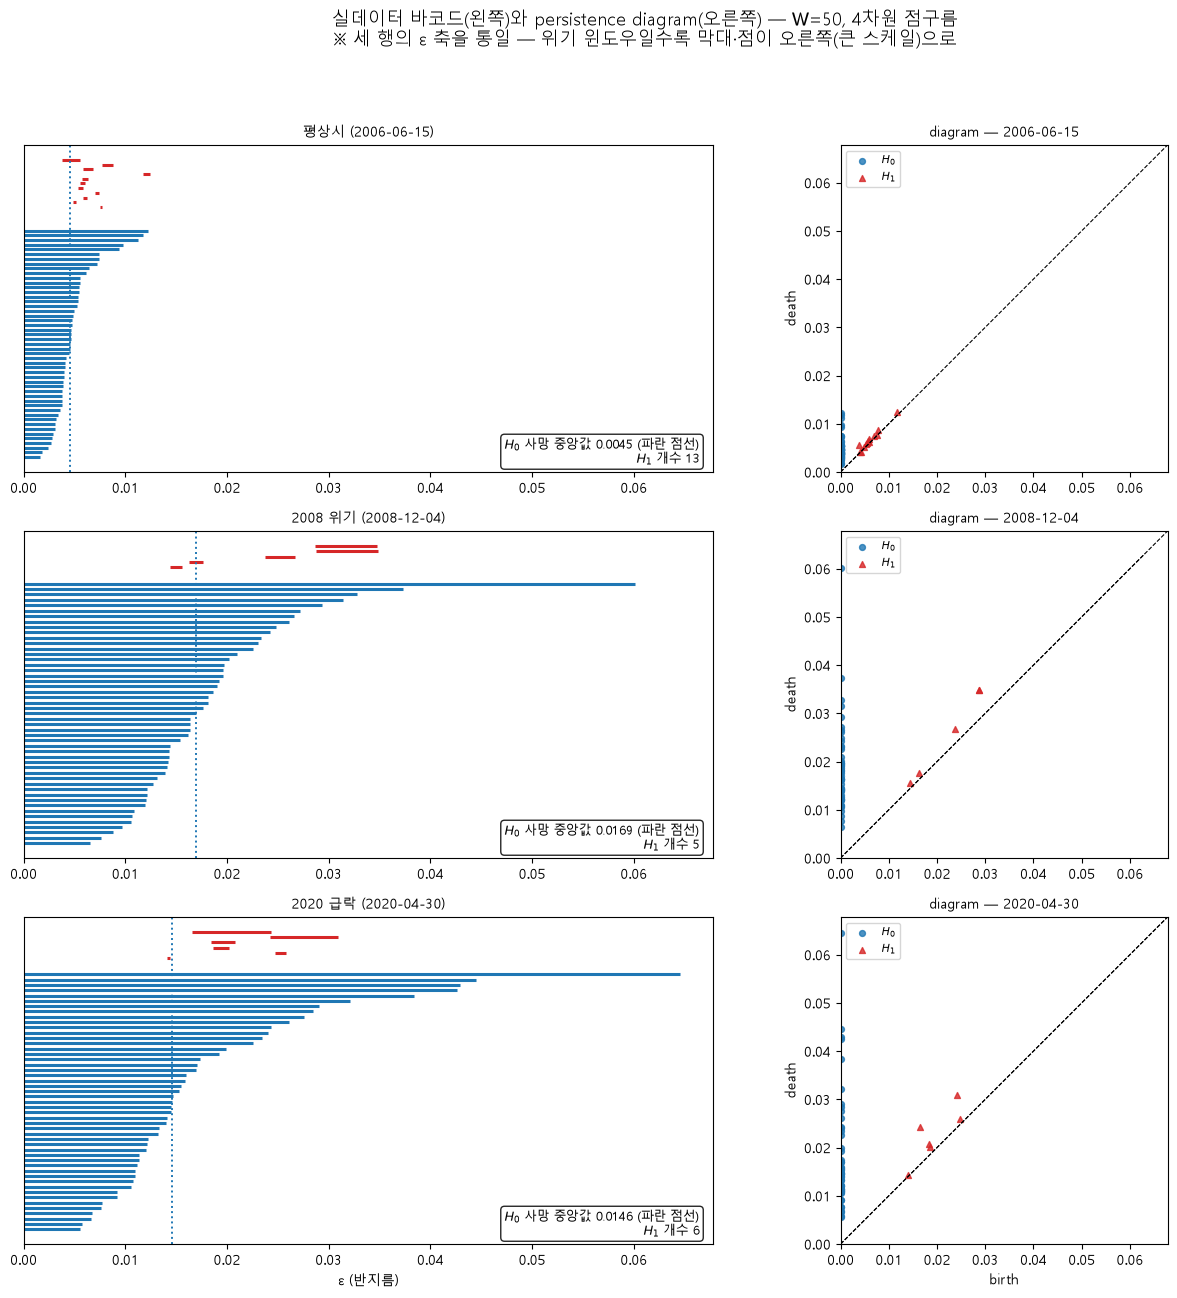

In [12]:
if RUN_VIZ:
    ex = [(label, *diagram_at(ds)) for label, ds in EXAMPLE_DATES.items()]
    # ex[i] = (label, dgm, pc, actual_date)

    # ε 축 통일 — 세 시점을 '같은 자'로 비교 (위기 때 구조가 몇 배 큰지 즉시 보이게)
    LIM = max(dgm[:, 1].max() for _, dgm, _, _ in ex) * 1.05

    fig, axes = plt.subplots(3, 2, figsize=(13, 13),
                             gridspec_kw={"width_ratios": [1.25, 1]})
    for row, (label, dgm, _, actual) in enumerate(ex):
        # ── 왼쪽: 바코드 ──
        axl = axes[row, 0]
        draw_barcode(axl, dgm, label)
        axl.set_xlim(0, LIM)
        if row < 2:
            axl.set_xlabel("")
        h0d = dgm[(dgm[:, 2] == 0) & (dgm[:, 1] > 0)][:, 1]
        h1b = dgm[(dgm[:, 2] == 1) & (dgm[:, 1] > dgm[:, 0])]
        axl.axvline(np.median(h0d), color="tab:blue", ls=":", lw=1.4)
        axl.text(0.98, 0.02,
                 f"$H_0$ 사망 중앙값 {np.median(h0d):.4f} (파란 점선)\n$H_1$ 개수 {len(h1b)}",
                 transform=axl.transAxes, ha="right", va="bottom", fontsize=9,
                 bbox=dict(boxstyle="round", fc="white", alpha=0.85))

        # ── 오른쪽: persistence diagram (같은 ε 스케일) ──
        axr = axes[row, 1]
        draw_diagram(axr, dgm, f"diagram — {actual.date()}")
        axr.plot([0, LIM], [0, LIM], "k--", lw=0.8)
        axr.set_xlim(0, LIM); axr.set_ylim(0, LIM)
        axr.set_aspect("equal")
        if row < 2:
            axr.set_xlabel("")

    plt.suptitle("실데이터 바코드(왼쪽)와 persistence diagram(오른쪽) — W=50, 4차원 점구름\n"
                 "※ 세 행의 ε 축을 통일 — 위기 윈도우일수록 막대·점이 오른쪽(큰 스케일)으로",
                 y=0.995, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("viz2_barcodes_real.png", dpi=140, bbox_inches="tight")
    plt.show()

### viz3. Betti 곡선 — "반지름을 키우면 구조가 어떻게 변하나"

 Betti 수 βₖ(ε) = 반지름 ε일 때 살아 있는 k차원 특징의 개수.
 - **β₀ 곡선**: 점 개수에서 시작해 1로 떨어지는 계단 — 떨어지는 "속도"가 점구름의 촘촘함.
   위기 윈도우는 점들이 흩어져 있어 곡선이 **더 큰 ε에서** 떨어짐.
 - **β₁ 곡선**: 고리가 살아 있는 구간에서 솟는 언덕 — 위기 윈도우가 더 오른쪽(큰 스케일)에서 활동.

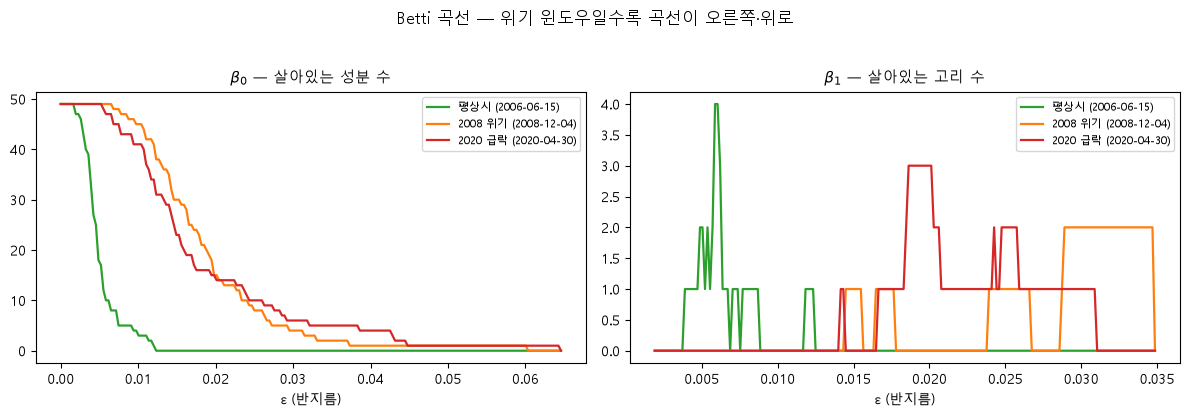

In [13]:
if RUN_VIZ:
    ex_dgms = np.stack([dgm for _, dgm, _, _ in ex])
    bc = BettiCurve(n_bins=200)
    curves = bc.fit_transform(ex_dgms)        # (3, 2, n_bins)
    eps_grid = bc.samplings_                   # {차원: 그리드}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ["tab:green", "tab:orange", "tab:red"]
    for dim, ax, name in [(0, axes[0], "$β_0$ — 살아있는 성분 수"),
                          (1, axes[1], "$β_1$ — 살아있는 고리 수")]:
        for i, (label, *_ ) in enumerate(ex):
            ax.plot(eps_grid[dim], curves[i, dim], color=colors[i], lw=1.6, label=label)
        ax.set_xlabel("ε (반지름)")
        ax.set_title(name, fontsize=11)
        ax.legend(fontsize=8)
    plt.suptitle("Betti 곡선 — 위기 윈도우일수록 곡선이 오른쪽·위로", y=1.03, fontsize=12)
    plt.tight_layout()
    plt.savefig("viz3_betti_curves.png", dpi=140, bbox_inches="tight")
    plt.show()

### viz4. 4차원 점구름 "엿보기" — PCA 2D 투영 + 4D 거리 기준 VR 엣지

 4차원 자체는 못 그리지만, PCA로 분산이 가장 큰 2개 방향에 투영해 "가장 넓은 단면"을 봄.
 엣지는 **그림의 2D 거리가 아니라 원래 4D 거리로** 판정 (진짜 VR 복합체의 그림자).

 > ⚠️ 정직한 한계: 투영이라 4D에서 먼 점이 겹쳐 보일 수 있음. "구조를 엄밀히 보는 그림"이 아니라
 > "위기 때 점구름이 얼마나 퍼지는지 감을 주는 그림"으로만 사용. (회의에서도 이 단서를 붙일 것)

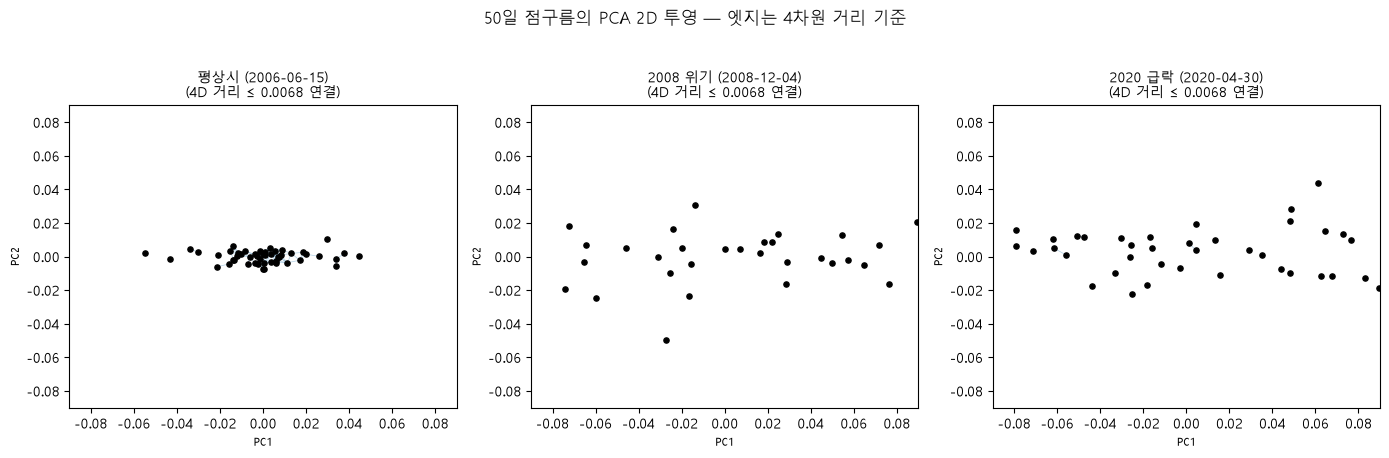

In [14]:
if RUN_VIZ:
    def draw_projected_window(ax, pc, eps, title):
        X = pc - pc.mean(0)
        _, _, Vt = np.linalg.svd(X, full_matrices=False)
        P = X @ Vt[:2].T
        D4 = squareform(pdist(pc))            # 거리는 4차원에서!
        for i in range(len(pc)):
            for j in range(i + 1, len(pc)):
                if D4[i, j] <= eps:
                    ax.plot(P[[i, j], 0], P[[i, j], 1], color="tab:blue", lw=0.5, alpha=0.35)
        ax.scatter(P[:, 0], P[:, 1], s=14, c="black", zorder=3)
        ax.set_xlabel("PC1", fontsize=8); ax.set_ylabel("PC2", fontsize=8)
        ax.set_title(title, fontsize=10)

    # 같은 ε·같은 축 스케일로 비교 (ε는 평상시 H0 사망 중앙값 × 1.5로 통일)
    d0 = ex[0][1]
    eps_common = float(np.median(d0[(d0[:, 2] == 0) & (d0[:, 1] > 0)][:, 1]) * 1.5)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    for ax, (label, _, pc, _) in zip(axes, ex):
        draw_projected_window(ax, pc, eps_common, f"{label}\n(4D 거리 ≤ {eps_common:.4f} 연결)")
        ax.set_xlim(-0.09, 0.09); ax.set_ylim(-0.09, 0.09)
    plt.suptitle("50일 점구름의 PCA 2D 투영 — 엣지는 4차원 거리 기준", y=1.03, fontsize=12)
    plt.tight_layout()
    plt.savefig("viz4_pointcloud_projection.png", dpi=140, bbox_inches="tight")
    plt.show()

 **읽는 법**: 평상시엔 점들이 좁게 뭉쳐 같은 ε에서 거의 전부 연결(엣지 빽빽).
 위기 윈도우는 점들이 넓게 흩어져 같은 ε로는 듬성듬성 — "같은 자로 쟀는데 구조가 다르다"가
 H₀/H₁ 차이의 기하학적 정체.

### viz5. persistence landscape — L¹/L² norm이 재는 "텐트 산맥"

 다이어그램의 각 특징 (b, d)를 **꼭짓점 높이 (d−b)/2인 텐트 함수**로 바꾸고,
 k번째로 높은 윤곽선을 λₖ라 함. §4의 `TDA_L1_H1`은 이 산맥(λ₁..λ₅)의 총면적.
 **위기 산맥이 눈에 띄게 높고 넓다** → 그 면적 차이가 §6 시계열에서 norm이 튀는 이유.


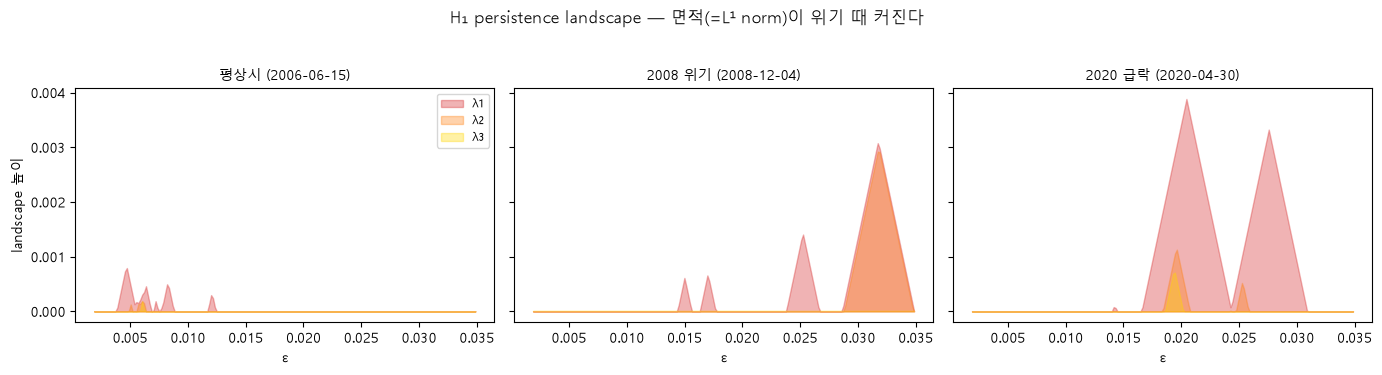

평상시 (2006-06-15)       H₁ landscape 면적 ≈ 0.000002
2008 위기 (2008-12-04)   H₁ landscape 면적 ≈ 0.000022
2020 급락 (2020-04-30)   H₁ landscape 면적 ≈ 0.000028


In [15]:
if RUN_VIZ:
    PL = PersistenceLandscape(n_layers=3, n_bins=200)
    land = PL.fit_transform(ex_dgms)          # (3, 2*n_layers, n_bins)
    grid = PL.samplings_[1]                   # H1 그리드

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
    layer_colors = ["tab:red", "tab:orange", "gold"]
    for ax, i, (label, *_ ) in zip(axes, range(3), ex):
        for k in range(3):
            ax.fill_between(grid, land[i, 3 + k], alpha=0.35, color=layer_colors[k],
                            label=f"λ{k+1}")
        ax.set_xlabel("ε")
        ax.set_title(label, fontsize=10)
    axes[0].set_ylabel("landscape 높이")
    axes[0].legend(fontsize=8)
    plt.suptitle("H₁ persistence landscape — 면적(=L¹ norm)이 위기 때 커진다", y=1.03, fontsize=12)
    plt.tight_layout()
    plt.savefig("viz5_landscapes.png", dpi=140, bbox_inches="tight")
    plt.show()

    areas = np.trapz(np.abs(land[:, 3:6, :]), grid, axis=-1).sum(axis=1)
    for (label, *_ ), a in zip(ex, areas):
        print(f"{label:22s} H₁ landscape 면적 ≈ {a:.6f}")

 > **회의 스토리라인 (그림 순서)**:
 > viz1(개념) → viz2(우리 데이터의 기록) → viz3(구조 변화) → viz4(점구름 감, 단서 필수)
 > → viz5(norm의 실체) → §6 시계열 그림. "개념 → 피처 → 시계열 → 위기 스파이크"가 한 줄로 이어짐.

# 6. [회의 산출물] 위기 구간 스파이크 검증

 **확인 목표**: L¹/L² norm이 2008 금융위기·2020 코로나 급락 구간에서 눈에 띄게 튀는가.
 (2022 약세장, 2025 관세 충격도 참고로 음영 표시)

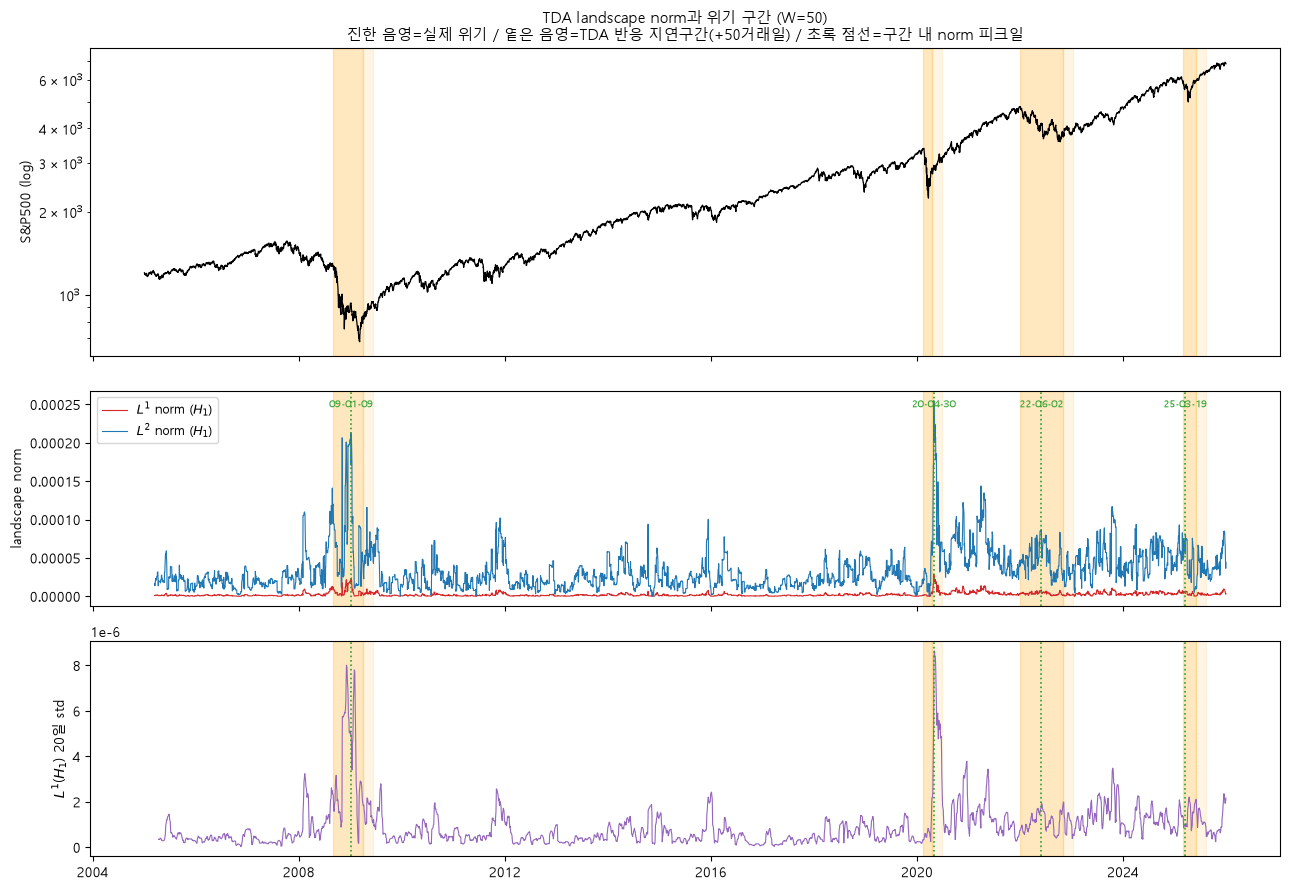

In [16]:
CRISES = [
    ("2008 금융위기", "2008-09-01", "2009-03-31"),
    ("2020 코로나",   "2020-02-15", "2020-04-15"),
    ("2022 약세장",   "2022-01-01", "2022-10-31"),
    ("2025 관세충격", "2025-03-01", "2025-05-31"),
]

def response_window(s, e, w=W_TDA):
    """실제 위기 구간 + 윈도우 지연(w 거래일) = TDA가 반응하는 구간.
    W=50 윈도우는 위기 데이터로 '가득 찰' 때 norm이 최대가 되므로 반응이 뒤로 밀림."""
    idx = tda_features.index
    i0 = idx.searchsorted(pd.Timestamp(s))
    i1 = min(idx.searchsorted(pd.Timestamp(e)) + w, len(idx) - 1)
    return idx[i0], idx[i1]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1.4, 1.4]})

axes[0].plot(close_df.index, close_df["GSPC"], lw=0.9, color="black")
axes[0].set_yscale("log")
axes[0].set_ylabel("S&P500 (log)")

axes[1].plot(tda_features.index, tda_features["TDA_L1_H1"], lw=0.8, color="tab:red", label="$L^1$ norm ($H_1$)")
axes[1].plot(tda_features.index, tda_features["TDA_L2_H1"], lw=0.8, color="tab:blue", label="$L^2$ norm ($H_1$)")
axes[1].set_ylabel("landscape norm")
axes[1].legend(loc="upper left", fontsize=9)

axes[2].plot(tda_features.index, tda_features["TDA_L1_H1_std20"], lw=0.8, color="tab:purple")
axes[2].set_ylabel("$L^1$($H_1$) 20일 std")

# 진한 음영 = 실제 위기 / 옅은 음영 = 반응 지연구간
for ax in axes:
    for name, s, e in CRISES:
        _, b = response_window(s, e)
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="orange", alpha=0.25)
        ax.axvspan(pd.Timestamp(e), b, color="orange", alpha=0.10)

# 초록 점선 = 각 반응구간 내 norm 피크일
for name, s, e in CRISES:
    a, b = response_window(s, e)
    pk = tda_features.loc[a:b, "TDA_L1_H1"].idxmax()
    for ax in axes[1:]:
        ax.axvline(pk, color="tab:green", ls=":", lw=1.2)
    axes[1].annotate(pk.strftime("%y-%m-%d"), xy=(pk, axes[1].get_ylim()[1] * 0.92),
                     fontsize=7, color="tab:green", ha="center")

axes[0].set_title(f"TDA landscape norm과 위기 구간 (W={W_TDA})\n"
                  "진한 음영=실제 위기 / 옅은 음영=TDA 반응 지연구간(+50거래일) / 초록 점선=구간 내 norm 피크일",
                  fontsize=11)
plt.tight_layout()
plt.savefig(f"tda_crisis_check_w{W_TDA}.png", dpi=140, bbox_inches="tight")
plt.show()

In [17]:
# 위기별 개별 보고 (중립 — 판정 없음)
#  ※ 이전 버전은 2008·2020을 합쳐 평균했는데, 2020 음영이 반응 지연 때문에
#    피크 직전에서 끝나 배율이 과소평가되고 2008이 그걸 가리는 문제가 있었음.
mask_any = pd.Series(False, index=tda_features.index)
for _, s, e in CRISES:
    a, b = response_window(s, e)
    mask_any |= (tda_features.index >= a) & (tda_features.index <= b)

cols = ["TDA_L1_H1", "TDA_L2_H1", "TDA_L1_H1_std20"]
base = tda_features.loc[~mask_any, cols].mean()   # 평상시 = 어떤 반응구간에도 없는 날

rows = []
for name, s, e in CRISES:
    a, b = response_window(s, e)
    seg = tda_features.loc[a:b]
    pk = seg["TDA_L1_H1"].idxmax()
    rows.append({
        "위기": name,
        "반응구간": f"{a.date()} ~ {b.date()}",
        "n": len(seg),
        "L1 배율": seg["TDA_L1_H1"].mean() / base["TDA_L1_H1"],
        "L2 배율": seg["TDA_L2_H1"].mean() / base["TDA_L2_H1"],
        "std20 배율": seg["TDA_L1_H1_std20"].mean() / base["TDA_L1_H1_std20"],
        "peak일": pk.date(),
        "peak 백분위": (tda_features["TDA_L1_H1"] < seg["TDA_L1_H1"].max()).mean() * 100,
    })
display(pd.DataFrame(rows).round(2))

print("\n※ 배율은 평상시 평균 대비. 판정 기준은 두지 않음 (3차 회의 합의).")
print("※ 반응구간 = 실제 위기 + 50거래일 — W=50 윈도우가 위기 데이터로 가득 차는 시점에 norm이 최대.")

,위기,반응구간,n,L1 배율,L2 배율,std20 배율,peak일,peak 백분위
0,2008 금융위기,2008-09-02 ~ 2009-06-11,196,2.93,2.41,4.30,2009-01-09,99.94
1,2020 코로나,2020-02-18 ~ 2020-06-25,91,3.25,2.50,4.42,2020-04-30,99.98
2,2022 약세장,2022-01-03 ~ 2023-01-12,259,1.62,1.46,1.49,2022-06-02,97.25
3,2025 관세충격,2025-03-03 ~ 2025-08-13,114,1.44,1.34,1.80,2025-03-19,94.92



※ 배율은 평상시 평균 대비. 판정 기준은 두지 않음 (3차 회의 합의).
※ 반응구간 = 실제 위기 + 50거래일 — W=50 윈도우가 위기 데이터로 가득 차는 시점에 norm이 최대.


#  7. 산출물 저장

 `tda_features_w{W}.csv` — Date 인덱스의 TDA 피처 8종.
 팀원 누구든 자기 노트북에서 날짜 기준 join만 하면 실험 ③(+TDA)을 돌릴 수 있음.

In [18]:
out_csv = f"tda_features_w{W_TDA}.csv"
tda_features.to_csv(out_csv, encoding="utf-8-sig")
print("저장 완료:", out_csv, tda_features.shape)

저장 완료: tda_features_w50.csv (5233, 8)


# 8. 공유 npz와 병합 — 실험 매트릭스 ①~④ 미니 데모

 전처리 통합본 §16의 `GSPC_arrays.npz`를 **그대로 로드**해 (전처리 코드는 손대지 않음)
 날짜 기준으로 TDA 피처를 붙인다.

 - **valid/test는 전 행 보존**: TDA 워밍업(W+20일)은 2005년 초 train 앞부분에만 걸림
 - 결과 보고는 팀 규약(§15)대로 **베이스라인 대비 격차만 중립 보고, 판정 없음**

In [19]:
d = np.load(NPZ_PATH, allow_pickle=True)
feat_cols = list(d["feature_columns"])

def restore(split):
    idx = pd.to_datetime(d[f"idx_{split}"])
    X = pd.DataFrame(d[f"X_{split}"], index=idx, columns=feat_cols)
    y = pd.Series(d[f"y_{split}_cls"], index=idx, name="y_updown")
    return X, y

X_train, y_train = restore("train")
X_valid, y_valid = restore("valid")
X_test,  y_test  = restore("test")
print("npz 로드:", X_train.shape, X_valid.shape, X_test.shape, "| meta:", list(d["meta"]))

npz 로드: (3654, 22) (782, 22) (783, 22) | meta: ['^GSPC', '2005-01-01', '2026-01-01', '1', 'True']


In [20]:
# 팀 공통 평가 함수 — 전처리 통합본 §14와 동일 (결과 컬럼을 팀 전체와 일치시키기 위함)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(y_true_cls, score, name="model", y_true_reg=None, pred_reg=None):
    score = np.asarray(score, dtype=float)
    y_true_cls = np.asarray(y_true_cls, dtype=int)
    thr = 0.5 if (score.min() >= 0.0 and score.max() <= 1.0) else 0.0
    y_pred = (score > thr).astype(int)
    out = {
        "model":    name,
        "accuracy": accuracy_score(y_true_cls, y_pred),
        "f1":       f1_score(y_true_cls, y_pred, zero_division=0),
        "roc_auc":  roc_auc_score(y_true_cls, score),
        "n":        len(y_true_cls),
    }
    if y_true_reg is not None and pred_reg is not None:
        from sklearn.metrics import mean_squared_error, r2_score
        out["rmse"] = float(np.sqrt(mean_squared_error(y_true_reg, pred_reg)))
        out["r2"]   = float(r2_score(y_true_reg, pred_reg))
    return out

print("팀 공통 evaluate() 정의 완료")

팀 공통 evaluate() 정의 완료


In [21]:
tda_cols   = list(tda_features.columns)
cross_cols = list(cross_features.columns)

# 교차·TDA를 먼저 합친 뒤 join → 모든 실험이 '동일 표본'에서 평가됨.
# ※ 따로 붙이면 워밍업 길이가 달라 실험마다 표본이 달라질 수 있음 (이번 실행에선 9행으로 동일)
extra = cross_features.join(tda_features, how="inner")

def attach(X, y):
    Xt = X.join(extra, how="inner").dropna(subset=cross_cols + tda_cols)
    return Xt, y.loc[Xt.index]

X_train_t, y_train_t = attach(X_train, y_train)
X_valid_t, y_valid_t = attach(X_valid, y_valid)
X_test_t,  y_test_t  = attach(X_test,  y_test)

print(f"train {len(X_train)} → {len(X_train_t)}  (워밍업 {len(X_train)-len(X_train_t)}행 제거 — 앞부분만)")
print(f"valid {len(X_valid)} → {len(X_valid_t)}  | test {len(X_test)} → {len(X_test_t)}  (전 행 보존이어야 정상)")
assert len(X_valid_t) == len(X_valid) and len(X_test_t) == len(X_test), \
    "valid/test 행이 줄었음 — 날짜 정합 확인 필요!"
print("※ 동일 표본 보장 → 아래 6개 실험의 수치를 나란히 비교 가능")

train 3654 → 3645  (워밍업 9행 제거 — 앞부분만)
valid 782 → 782  | test 783 → 783  (전 행 보존이어야 정상)
※ 동일 표본 보장 → 아래 6개 실험의 수치를 나란히 비교 가능


In [ ]:
# =============================================================================
# 금융_TDA_김소현_v2.ipynb  §8 실험 매트릭스 셀 — 교체본
#
# 기존 셀(RandomForest 1회 학습)을 이 셀로 통째로 바꿔 실행하세요.
# 앞 셀(§8의 npz 로드·evaluate 정의·X_train_t 병합)은 그대로 두시면 됩니다.
#
# 바뀐 것 3가지
#   1) 시드 7개 평균 — 소진 님과 동일한 (0,1,2,3,4,42,100)
#      ※ 공통코드 §8 예시가 사람마다 다른 시드를 주고 있었음. 여기서 통일.
#   2) ⑥ 이름을 공통코드와 동일하게 "⑥ 저중복 TDA (5)"로 (피처는 그대로)
#   3) ⑦ +저중복TDA (22+5) 추가
#
# 소요: 약 2~3분 (RF 300그루 × 9실험 × 7시드)
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             balanced_accuracy_score)

SEEDS = (0, 1, 2, 3, 4, 42, 100)          # ★ 팀 통일 시드

vol_cols    = [c for c in feat_cols if c.startswith("Volatility_")]
lowcorr_tda = ["TDA_L1_H1", "TDA_L2_H1", "TDA_PE_H1", "TDA_PE_H0", "TDA_L1_H1_diff1"]
#              ↑ train 구간에서 Volatility_20과 |상관| < 0.5 인 것만 (§8 마지막 셀 상관표 참조)

EXPERIMENTS = {
    "① 베이스라인 (22)":     feat_cols,
    "② +교차지수 (22+12)":   feat_cols + cross_cols,
    "③ +TDA (22+8)":        feat_cols + tda_cols,
    "②+③ 전부 (22+20)":     feat_cols + cross_cols + tda_cols,
    "④ TDA만 (8)":          tda_cols,
    "④' 교차지수만 (12)":    cross_cols,
    "⑤ 변동성만 (4)":        vol_cols,
    "⑥ 저중복 TDA (5)":      lowcorr_tda,
    "⑦ +저중복TDA (22+5)":   feat_cols + lowcorr_tda,      # ★ 신규
}

maj      = int(round(y_train_t.mean()))
base_acc = float((y_valid_t == maj).mean())

rows, probs = [], {}
for name, cols in EXPERIMENTS.items():
    preds, seed_accs = [], []
    for s in SEEDS:
        rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                    random_state=s, n_jobs=-1)
        rf.fit(X_train_t[cols], y_train_t)
        q = rf.predict_proba(X_valid_t[cols])[:, 1]
        preds.append(q)
        seed_accs.append(accuracy_score(y_valid_t, (q > 0.5).astype(int)))

    p = np.mean(preds, axis=0)              # 시드 평균 예측확률
    probs[name] = p
    yp = (p > 0.5).astype(int)

    rows.append({
        "model": "RandomForest", "experiment": name, "n_feat": len(cols),
        "accuracy":     accuracy_score(y_valid_t, yp),
        "baseline_acc": base_acc,
        "gap_pp":       (accuracy_score(y_valid_t, yp) - base_acc) * 100,
        "balanced_acc": balanced_accuracy_score(np.asarray(y_valid_t, int), yp),
        "roc_auc":      roc_auc_score(y_valid_t, p),
        "f1":           f1_score(y_valid_t, yp, zero_division=0),
        "n": len(y_valid_t), "split": "valid",
        "acc_std_seed": float(np.std(seed_accs, ddof=1)),
    })

demo = pd.DataFrame(rows).round(4)
front = ["model", "experiment", "n_feat", "accuracy", "baseline_acc", "gap_pp",
         "balanced_acc", "roc_auc", "f1", "n", "split", "acc_std_seed"]
demo = demo[front]
display(demo)
print(f"\n다수 클래스 베이스라인 accuracy = {base_acc:.4f} (valid)")
print(f"시드 {len(SEEDS)}개 평균 — 소진 님과 동일 집합")

demo.to_csv("matrix_소현.csv", index=False, encoding="utf-8-sig")
print("저장: matrix_소현.csv")


# ── 기대 출력 (검산용) ────────────────────────────────────────────────────
#   같은 데이터·같은 코드면 아래와 정확히 같아야 합니다.
#
#   실험                    accuracy   gap_pp  balanced  roc_auc      f1  std_seed
#   ① 베이스라인 (22)          0.5537   1.2788    0.5320   0.5459  0.6588   0.0061
#   ② +교차지수 (22+12)       0.5537   1.2788    0.5327   0.5265  0.6568   0.0082
#   ③ +TDA (22+8)          0.5524   1.1509    0.5332   0.5564  0.6500   0.0056
#   ②+③ 전부 (22+20)         0.5448   0.3836    0.5284   0.5380  0.6337   0.0062
#   ④ TDA만 (8)             0.5051  -3.5806    0.4852   0.4813  0.6142   0.0064
#   ④' 교차지수만 (12)         0.5102  -3.0691    0.4902   0.4865  0.6189   0.0047
#   ⑤ 변동성만 (4)            0.5243  -1.6624    0.5074   0.5138  0.6189   0.0100
#   ⑥ 저중복 TDA (5)         0.5345  -0.6394    0.5154   0.5084  0.6353   0.0070
#   ⑦ +저중복TDA (22+5)      0.5563   1.5345    0.5388   0.5578  0.6470   0.0070
#
#   ※ 안 맞으면 sklearn 버전이 다른 것이니 그 사실만 회의에서 공유하세요.
#     (seed 42 단일 실행 결과는 기존 노트북 §8과 소수점 4자리까지 일치함을 확인했습니다)


# ── 이어서: 부트스트랩 CI (기존 §8 다음 셀 그대로 쓰되 COMPARISONS만 교체) ──
COMPARISONS = [
    ("① 베이스라인 (22)",   "② +교차지수 (22+12)"),
    ("① 베이스라인 (22)",   "③ +TDA (22+8)"),
    ("① 베이스라인 (22)",   "⑦ +저중복TDA (22+5)"),   # ★ 핵심 비교
    ("② +교차지수 (22+12)", "②+③ 전부 (22+20)"),
    ("⑤ 변동성만 (4)",      "④ TDA만 (8)"),
    ("④ TDA만 (8)",        "⑥ 저중복 TDA (5)"),
    ("⑤ 변동성만 (4)",      "⑥ 저중복 TDA (5)"),
]

crows = []
for a, b in COMPARISONS:
    m, lo, hi = boot_auc_diff(y_valid_t, probs[a], probs[b])
    crows.append({"비교": f"{a} → {b}", "ΔAUC": m,
                  "95% CI 하한": lo, "95% CI 상한": hi,
                  "0 포함": "예" if lo <= 0 <= hi else "아니오"})
display(pd.DataFrame(crows).round(4))
print("\n※ CI가 0을 포함하면 '이 표본에서 차이가 확인되지 않음'이 정확한 표현.")

# ── 기대 출력 (검산용) ────────────────────────────────────────────────────
#   ① → ②   -0.0195  [-0.0434, +0.0048]  예
#   ① → ③   +0.0105  [-0.0065, +0.0276]  예
#   ① → ⑦   +0.0119  [-0.0044, +0.0279]  예     ← 세 모델 중 유일하게 전부 양수
#   ② → ②+③ +0.0115  [-0.0025, +0.0264]  예
#   ⑤ → ④   -0.0319  [-0.0831, +0.0234]  예
#   ④ → ⑥   +0.0273  [-0.0070, +0.0598]  예
#   ⑤ → ⑥   -0.0047  [-0.0626, +0.0530]  예

In [29]:
# 실험 매트릭스 ①~④ — 같은 RF·같은 표본, 피처 조합만 교체
# ※ 배선 확인용. 본 매트릭스는 Ridge/Lasso(다영)·XGBoost(서연)·Bagging(소진)에서 각각 수행 예정.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

vol_cols = [c for c in feat_cols if c.startswith("Volatility_")]
h1_cols = ["TDA_L1_H1", "TDA_L2_H1", "TDA_PE_H1", "TDA_PE_H0", "TDA_L1_H1_diff1"]

EXPERIMENTS = {
    "① 베이스라인 (22)":   feat_cols,
    "② +교차지수 (22+12)": feat_cols + cross_cols,
    "③ +TDA (22+8)":      feat_cols + tda_cols,
    "②+③ 전부 (22+20)":   feat_cols + cross_cols + tda_cols,
    "④ TDA만 (8)":        tda_cols,
    "④' 교차지수만 (12)":  cross_cols,
    "⑤ 변동성만 (4)":      vol_cols,      # 추가
     "⑥ 저중복 TDA (5)":  h1_cols,
}

maj = int(round(y_train_t.mean()))          # 팀 규약(§15): train 다수 클래스 기준
base_acc = (y_valid_t == maj).mean()

rows, models, probs = [], {}, {}
for name, cols in EXPERIMENTS.items():
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_t[cols], y_train_t)
    p = rf.predict_proba(X_valid_t[cols])[:, 1]
    probs[name] = p
    models[name] = (rf, cols)

    res = evaluate(y_valid_t, p, name=name)          # 팀 공통 함수
    res["n_feat"] = len(cols)
    res["baseline_acc"] = base_acc
    res["gap_pp"] = (res["accuracy"] - base_acc) * 100
    rows.append(res)

demo = pd.DataFrame(rows).round(4)
display(demo)
print(f"\n다수 클래스 베이스라인 accuracy = {base_acc:.4f} (valid)")
print("※ 판정 없음 — 격차 해석 기준은 전원 결과 취합 후 함께 정하기로 함 (3차 회의 합의).")

,model,accuracy,f1,roc_auc,n,n_feat,baseline_acc,gap_pp
0,① 베이스라인 (22),0.5512,0.6549,0.5433,782,22,0.5409,1.0230
1,② +교차지수 (22+12),0.5371,0.6479,0.5385,782,34,0.5409,-0.3836
2,③ +TDA (22+8),0.5550,0.6575,0.5581,782,30,0.5409,1.4066
3,②+③ 전부 (22+20),0.5371,0.6213,0.5288,782,42,0.5409,-0.3836
4,④ TDA만 (8),0.5064,0.6193,0.4748,782,8,0.5409,-3.4527
5,④' 교차지수만 (12),0.5128,0.6171,0.4893,782,12,0.5409,-2.8133
6,⑤ 변동성만 (4),0.5358,0.6285,0.5116,782,4,0.5409,-0.5115
7,⑥ TDA-H₁계열만 (5),0.5384,0.6357,0.5063,782,5,0.5409,-0.2558



다수 클래스 베이스라인 accuracy = 0.5409 (valid)
※ 판정 없음 — 격차 해석 기준은 전원 결과 취합 후 함께 정하기로 함 (3차 회의 합의).


In [30]:
# ①→③ 등 핵심 비교의 AUC 차이에 95% 부트스트랩 신뢰구간
#  ※ AUC 차이의 크기만으로는 우연 여부를 알 수 없으므로 CI를 함께 보고
def boot_auc_diff(y, p_a, p_b, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=int); p_a = np.asarray(p_a); p_b = np.asarray(p_b)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y[idx], p_b[idx]) - roc_auc_score(y[idx], p_a[idx]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return float(np.mean(diffs)), lo, hi

COMPARISONS = [
    ("① 베이스라인 (22)",   "② +교차지수 (22+12)"),
    ("① 베이스라인 (22)",   "③ +TDA (22+8)"),
    ("② +교차지수 (22+12)", "②+③ 전부 (22+20)"),
    ("⑤ 변동성만 (4)",      "④ TDA만 (8)"),     # ← 추가
    ("④ TDA만 (8)",        "⑥ TDA-H₁계열만 (5)"),   # 희석 가설 검증
    ("⑤ 변동성만 (4)",      "⑥ TDA-H₁계열만 (5)"),   # H₁ vs 변동성 정면 비교
]
crows = []
for a, b in COMPARISONS:
    m, lo, hi = boot_auc_diff(y_valid_t, probs[a], probs[b])
    crows.append({"비교": f"{a} → {b}", "ΔAUC": m,
                  "95% CI 하한": lo, "95% CI 상한": hi,
                  "0 포함": "예" if lo <= 0 <= hi else "아니오"})
display(pd.DataFrame(crows).round(4))
print("\n※ CI가 0을 포함하면 '이 표본에서 차이가 통계적으로 확인되지 않음'이 정확한 표현.")
print("※ valid 782개 기준이라 CI가 넓음 — 세 방법론(Ridge·XGBoost·Bagging) 결과를 모아 함께 판단.")

,비교,ΔAUC,95% CI 하한,95% CI 상한,0 포함
0,① 베이스라인 (22) → ② +교차지수 (22+12),-0.0050,-0.0331,0.0223,예
1,① 베이스라인 (22) → ③ +TDA (22+8),0.0146,-0.0067,0.0368,예
2,② +교차지수 (22+12) → ②+③ 전부 (22+20),-0.0098,-0.0306,0.0117,예
3,⑤ 변동성만 (4) → ④ TDA만 (8),-0.0364,-0.0887,0.0186,예
4,④ TDA만 (8) → ⑥ TDA-H₁계열만 (5),0.0319,-0.0017,0.0639,예
5,⑤ 변동성만 (4) → ⑥ TDA-H₁계열만 (5),-0.0045,-0.0630,0.0531,예



※ CI가 0을 포함하면 '이 표본에서 차이가 통계적으로 확인되지 않음'이 정확한 표현.
※ valid 782개 기준이라 CI가 넓음 — 세 방법론(Ridge·XGBoost·Bagging) 결과를 모아 함께 판단.


In [25]:
# 피처 그룹별 기여도 (②+③ 모델 기준, 참고용)
rf3, cols3 = models["②+③ 전부 (22+20)"]
imp = pd.Series(rf3.feature_importances_, index=cols3).sort_values(ascending=False)

print("Feature importance 상위 15 (참고용):")
display(imp.head(15).round(4).to_frame("importance"))

grp = pd.Series({
    "22 기본피처":  imp[feat_cols].sum(),
    "교차지수(12)": imp[cross_cols].sum(),
    "TDA(8)":      imp[tda_cols].sum(),
})
n_each = [len(feat_cols), len(cross_cols), len(tda_cols)]
print("\n그룹별 importance 합 (피처 개수가 다르므로 '개당평균'을 함께 봄):")
display(pd.DataFrame({"합": grp.round(4), "개수": n_each,
                      "개당평균": (grp / n_each).round(5)}))
print("※ RF importance는 상관 피처끼리 기여를 나눠 갖는 성질이 있어 순위는 참고용.")

Feature importance 상위 15 (참고용):


,importance
X_exc5d_IXIC,0.0326
TDA_PE_H0,0.0314
Close_Location,0.0298
Volume_Z_20,0.0294
ret_lag5,0.0291
ret_lag1,0.0290
Gap_Return,0.0289
X_lead_RUT_1d,0.0287
Intraday_Return,0.0282
Return_20d,0.0275



그룹별 importance 합 (피처 개수가 다르므로 '개당평균'을 함께 봄):


,합,개수,개당평균
22 기본피처,0.5784,22,0.02629
교차지수(12),0.2917,12,0.02431
TDA(8),0.1300,8,0.01625


※ RF importance는 상관 피처끼리 기여를 나눠 갖는 성질이 있어 순위는 참고용.


In [26]:
print(X_train_t[tda_cols + ["Volatility_20"]].corr()["Volatility_20"][tda_cols].round(3))

TDA_L1_H0          0.813
TDA_L1_H1          0.462
TDA_L2_H0          0.805
TDA_L2_H1          0.462
TDA_PE_H0         -0.075
TDA_PE_H1         -0.223
TDA_L1_H1_diff1    0.017
TDA_L1_H1_std20    0.643
Name: Volatility_20, dtype: float64



# 9. (선택) 윈도우 민감도 — W ∈ {40, 80, 100}

 원 논문 구현이 여러 윈도우로 반복한 것과 같은 취지. 기본은 꺼둠 (계산 수 분 추가).

In [27]:
if RUN_SENSITIVITY:
    for w in [40, 80, 100]:
        pcs_w, dates_w = build_point_clouds(logret, w)
        dgms_w = compute_diagrams(pcs_w)
        f_w = diagrams_to_features(dgms_w, dates_w)
        f_w.to_csv(f"tda_features_w{w}.csv", encoding="utf-8-sig")

        fig, ax = plt.subplots(figsize=(12, 2.6))
        ax.plot(f_w.index, f_w["TDA_L1_H1"], lw=0.7, color="tab:red")
        for name, s, e in CRISES:
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="orange", alpha=0.15)
        ax.set_title(f"L¹ norm (H₁), W={w}", fontsize=10)
        plt.tight_layout()
        plt.savefig(f"tda_crisis_check_w{w}.png", dpi=140, bbox_inches="tight")
        plt.show()
else:
    print("민감도 분석 꺼짐 (RUN_SENSITIVITY=True로 활성화)")

민감도 분석 꺼짐 (RUN_SENSITIVITY=True로 활성화)


# 10. 최종 점검 체크리스트

In [28]:
checks = {
    "4개 지수 공통 거래일 join":     close_df.notna().all().all(),
    "로그 수익률 유한값":            np.isfinite(logret.values).all(),
    "TDA 피처 날짜 = 윈도우 끝(누수 없음)": tda_features.index[0] == logret.index[W_TDA - 1],
    "npz 병합 후 valid/test 행 보존": len(X_valid_t) == len(X_valid) and len(X_test_t) == len(X_test),
    "TDA 피처 CSV 저장":            os.path.exists(out_csv),
    "위기 검증 그림 저장":           os.path.exists(f"tda_crisis_check_w{W_TDA}.png"),
}
if RUN_VIZ:
    for f in ["viz1_vr_growth_toy.png", "viz2_barcodes_real.png", "viz3_betti_curves.png",
              "viz4_pointcloud_projection.png", "viz5_landscapes.png"]:
        checks[f"시각화 저장: {f}"] = os.path.exists(f)

for k, v in checks.items():
    print(("✓" if v else "✗"), k)
assert all(checks.values()), "체크리스트 실패 항목 있음"
print("\nTDA 파트 완료 — 회의 자료: viz1~5 (개념) → tda_crisis_check (검증) → §8 표 (팀 연결).")

✓ 4개 지수 공통 거래일 join
✓ 로그 수익률 유한값
✓ TDA 피처 날짜 = 윈도우 끝(누수 없음)
✓ npz 병합 후 valid/test 행 보존
✓ TDA 피처 CSV 저장
✓ 위기 검증 그림 저장
✓ 시각화 저장: viz1_vr_growth_toy.png
✓ 시각화 저장: viz2_barcodes_real.png
✓ 시각화 저장: viz3_betti_curves.png
✓ 시각화 저장: viz4_pointcloud_projection.png
✓ 시각화 저장: viz5_landscapes.png

TDA 파트 완료 — 회의 자료: viz1~5 (개념) → tda_crisis_check (검증) → §8 표 (팀 연결).
